# Where does the sales team's effort go?

**Context.** A B2B paint brand ran its sales process in Pipedrive (2020–2023): three sales reps, ~550 accounts (art supply stores, paint stores, workshops, distributors) and ~2,500 deals. The hypothesis from management: *the team is not spending its effort (calls, visits, follow-ups) where the revenue is.*

**Questions**
1. How are sales activities distributed across account tiers, compared with the revenue each tier brings?
2. How concentrated is revenue?
3. How do reps differ in volume and effort?
4. How long does each pipeline take to close?

This notebook reproduces, in Python, the analysis I originally built as a Power BI dashboard for my Data Analytics final project. **The dataset is anonymized**: account names and rep names are replaced, deal values are rescaled with noise, and free-text fields were removed. Patterns and proportions are preserved.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold"})
deals = pd.read_csv("data/crm_deals_anonymized.csv", parse_dates=["deal_created", "deal_closed"])
print(f"{len(deals):,} deals · {deals.account.nunique():,} accounts · {deals.deal_created.min():%b %Y} to {deals.deal_created.max():%b %Y}")
deals.head()

2,563 deals · 551 accounts · May 2020 to Apr 2023


,deal_id,account,pipeline,stage,deal_value,sales_rep,deal_created,deal_closed,deal_activities_done,account_tier,account_province,account_store_type,account_tax_status,account_discount_pct,account_payment_terms,account_activities_done,account_deals_won
0,1,Account 0001,Orders,Shipped on credit,928254.0,Rep A,2023-02-07,2023-04-12,1,Strategic,NaN,NaN,Exempt,0.0,NaN,1.0,1.0
1,2,Account 0002,Orders,Shipped on credit,715395.0,Rep A,2022-05-12,2022-07-07,1,Strategic,CABA,Paint store,VAT registered,30.0,Open account,5.0,7.0
2,3,Account 0003,Orders,Shipped on credit,631053.0,Rep A,2023-02-14,2023-03-09,1,NaN,Cordoba,Distributor,VAT registered,28.0,60 days,2.0,2.0
3,4,Account 0003,Orders,Shipped on credit,514906.0,Rep A,2023-02-14,2023-03-09,1,NaN,Cordoba,Distributor,VAT registered,28.0,60 days,2.0,2.0
4,5,Account 0004,Orders,Shipped on credit,380421.0,Rep A,2022-11-25,2023-01-20,2,Key,Salta,Art supply store,Simplified regime,22.0,Open account,13.0,6.0


## 1. Effort vs. revenue by account tier
Tiers are assigned manually by the sales team (Strategic → Key → Potential → Standard → Low → Churned). Effort = completed activities logged on the deals.

In [2]:
TIER_ORDER = ["Strategic", "Key", "Potential", "Standard", "Low", "Churned"]
tiered = deals.dropna(subset=["account_tier"])
by_tier = (tiered.groupby("account_tier")
           .agg(accounts=("account", "nunique"), revenue=("deal_value", "sum"), activities=("deal_activities_done", "sum"))
           .reindex(TIER_ORDER))
by_tier["revenue_share_%"] = by_tier.revenue / by_tier.revenue.sum() * 100
by_tier["effort_share_%"] = by_tier.activities / by_tier.activities.sum() * 100
by_tier["revenue_per_activity"] = by_tier.revenue / by_tier.activities
by_tier.round(1)

,accounts,revenue,activities,revenue_share_%,effort_share_%,revenue_per_activity
account_tier,,,,,,
Strategic,20,13705974.0,119,20.2,6.1,115176.3
Key,37,7822567.0,278,11.5,14.2,28138.7
Potential,76,16444112.0,442,24.2,22.7,37203.9
Standard,188,20561695.0,806,30.3,41.3,25510.8
Low,132,5540458.0,242,8.2,12.4,22894.5
Churned,87,3833633.0,64,5.6,3.3,59900.5


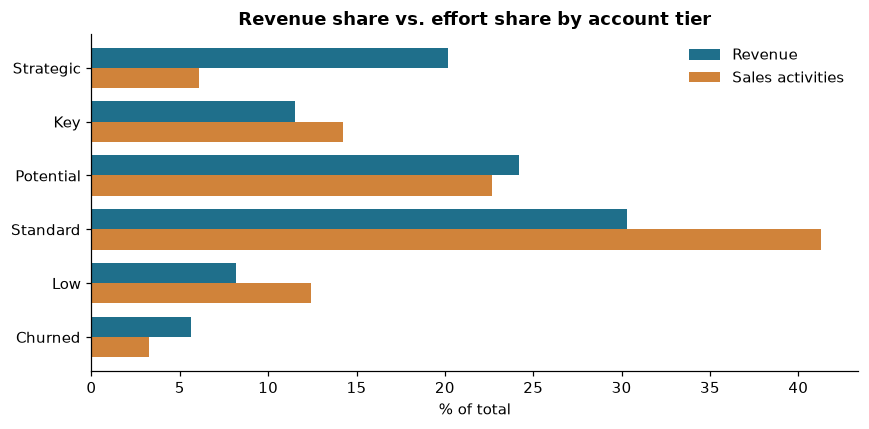

In [3]:
ax = by_tier[["revenue_share_%", "effort_share_%"]].plot.barh(figsize=(8, 4), color=["#1f6f8b", "#d0833a"], width=0.75)
ax.invert_yaxis(); ax.set_xlabel("% of total"); ax.set_ylabel("")
ax.set_title("Revenue share vs. effort share by account tier")
ax.legend(["Revenue", "Sales activities"], frameon=False)
plt.tight_layout(); plt.savefig("images/effort_vs_revenue.png", dpi=130); plt.show()

In [4]:
strategic, standard = by_tier.loc["Strategic"], by_tier.loc["Standard"]
print(f"Strategic accounts: {strategic.accounts:.0f} accounts, {strategic['revenue_share_%']:.0f}% of revenue with {strategic['effort_share_%']:.0f}% of activities.")
print(f"Standard accounts: {standard.accounts:.0f} accounts, {standard['revenue_share_%']:.0f}% of revenue with {standard['effort_share_%']:.0f}% of activities.")
print(f"Revenue per activity is {strategic.revenue_per_activity / standard.revenue_per_activity:.1f}x higher in Strategic than in Standard.")

Strategic accounts: 20 accounts, 20% of revenue with 6% of activities.
Standard accounts: 188 accounts, 30% of revenue with 41% of activities.
Revenue per activity is 4.5x higher in Strategic than in Standard.


## 2. Revenue concentration

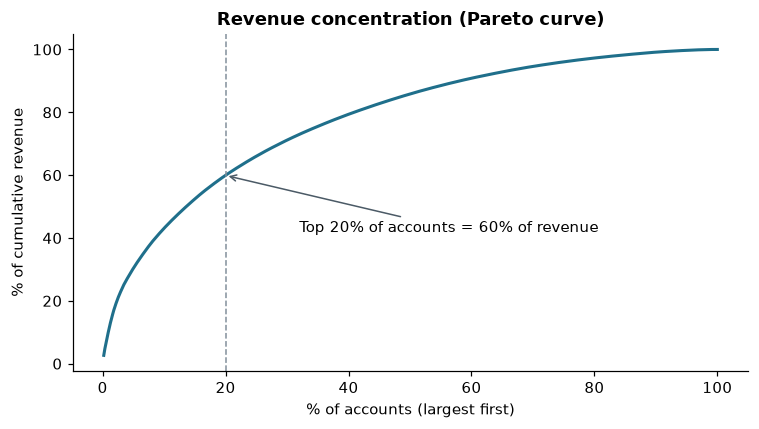

In [5]:
per_account = deals.groupby("account").deal_value.sum().sort_values(ascending=False)
cum = per_account.cumsum() / per_account.sum() * 100
share_accounts = [i / len(per_account) * 100 for i in range(1, len(per_account) + 1)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(share_accounts, cum.values, color="#1f6f8b", lw=2)
ax.axvline(20, color="#82909b", ls="--", lw=1)
top20 = cum.iloc[int(len(cum) * 0.2) - 1]
ax.annotate(f"Top 20% of accounts = {top20:.0f}% of revenue", xy=(20, top20), xytext=(32, top20 - 18), arrowprops=dict(arrowstyle="->", color="#4b5a66"))
ax.set_xlabel("% of accounts (largest first)"); ax.set_ylabel("% of cumulative revenue"); ax.set_title("Revenue concentration (Pareto curve)")
plt.tight_layout(); plt.savefig("images/pareto.png", dpi=130); plt.show()

## 3. Sales reps: volume and effort

In [6]:
reps = deals.groupby("sales_rep").agg(deals=("deal_id", "count"), accounts=("account", "nunique"),
                                      revenue=("deal_value", "sum"), activities=("deal_activities_done", "sum"))
reps["activities_per_deal"] = reps.activities / reps.deals
reps["revenue_per_activity"] = reps.revenue / reps.activities
reps.round(1)

,deals,accounts,revenue,activities,activities_per_deal,revenue_per_activity
sales_rep,,,,,,
Rep A,1656,500,52891576.0,1118,0.7,47309.1
Rep B,223,142,9638012.0,494,2.2,19510.1
Rep C,684,192,14440752.0,1670,2.4,8647.2


## 4. Time to close by pipeline

In [7]:
deals["days_to_close"] = (deals.deal_closed - deals.deal_created).dt.days
cycle = deals.groupby("pipeline").days_to_close.describe()[["count", "25%", "50%", "75%"]]
cycle.sort_values("50%")

,count,25%,50%,75%
pipeline,,,,
Orders,2091.0,8.0,15.0,33.0
Social media lead form,25.0,16.0,23.0,44.0
Reseller onboarding,33.0,17.0,28.0,120.0
Internal,1.0,226.0,226.0,226.0
Active customers,413.0,213.0,496.0,740.0


## Findings and recommendations

- **Effort is misallocated.** Strategic accounts bring a revenue share several times larger than the effort they receive, while Standard and Low accounts absorb over half of all logged activities for a smaller revenue share. Revenue per activity in Strategic accounts is several times that of Standard ones.
- **Revenue is concentrated**: roughly a fifth of the accounts produce close to 60% of revenue, which makes the retention of the top tier the main commercial risk.
- **Reps work very differently**: one rep handles most of the volume with few logged activities per deal, another logs many more activities per deal. Before comparing performance, activity logging needs a shared definition.
- **Most deals have no logged activity** (over 60%), so the activity data understates real effort. Making logging part of the process is a prerequisite for any effort-based KPI.

**Recommended actions:** a minimum contact cadence per tier (more touchpoints for Strategic and Key, automated reorder reminders for Standard and Low), a monthly tier review, and a dashboard that tracks effort share vs. revenue share per rep. These ideas later shaped the ERP setup: customer tiers as tags, repurchase-rhythm alerts and weekly account statements per broker.